# 🎙️ Deepfake Audio Detection — Pipeline Validation
**Owner:** Data / Preprocessing teammate  
**Purpose:** Verify every layer of the data pipeline is working correctly before handing off to the model team.

### What this notebook checks
1. Environment & imports
2. Dataset folder structure
3. Raw audio loading
4. Mel spectrogram extraction
5. Dataset class & sample counts
6. TF DataLoader output shapes & types
7. Class balance
8. Visual inspection of mel spectrograms
9. Waveform comparison (real vs fake)
10. ✅ Final handoff checklist

In [5]:
import os
print("Jupyter is running from:", os.getcwd())

Jupyter is running from: D:\deepfake_audio_detection\notebooks


---
## 1. Environment & Imports

In [20]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # suppress TF oneDNN warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Make sure we can import from src/
# The notebook is in notebooks/, so we go one level up
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import tensorflow as tf

print(f'Python     : {sys.version.split()[0]}')
print(f'NumPy      : {np.__version__}')
print(f'Librosa    : {librosa.__version__}')
print(f'SoundFile  : {sf.__version__}')
print(f'TensorFlow : {tf.__version__}')
print()
print('✅ All imports successful')

Python     : 3.13.5
NumPy      : 2.4.6
Librosa    : 0.11.0
SoundFile  : 0.13.1
TensorFlow : 2.21.0

✅ All imports successful


---
## 2. Dataset Folder Structure

In [21]:
DATASET_DIR = '../data/raw/for-2seconds'
PRESET      = 'for-2sec'
SPLITS      = ['training', 'validation', 'testing']
CLASSES     = ['real', 'fake']

print('Checking folder structure...\n')
all_ok = True

for split in SPLITS:
    for cls in CLASSES:
        folder = Path(DATASET_DIR) / split / cls
        exists = folder.exists()
        n_files = len(list(folder.glob('*.wav'))) if exists else 0
        status = '✅' if exists and n_files > 0 else '❌'
        if not (exists and n_files > 0):
            all_ok = False
        print(f'  {status}  {split:12s} / {cls:6s}  →  {n_files:>6,} wav files')

print()
print('✅ Folder structure OK' if all_ok else '❌ Some folders are missing or empty!')

Checking folder structure...

  ✅  training     / real    →   6,978 wav files
  ✅  training     / fake    →   6,978 wav files
  ✅  validation   / real    →   1,413 wav files
  ✅  validation   / fake    →   1,413 wav files
  ✅  testing      / real    →     544 wav files
  ✅  testing      / fake    →     544 wav files

✅ Folder structure OK


---
## 3. Raw Audio Loading

In [22]:
# Pick one real and one fake file from training
real_files = sorted((Path(DATASET_DIR) / 'training' / 'real').glob('*.wav'))
fake_files = sorted((Path(DATASET_DIR) / 'training' / 'fake').glob('*.wav'))

sample_real_path = real_files[0]
sample_fake_path = fake_files[0]

real_audio, real_sr = sf.read(str(sample_real_path), dtype='float32')
fake_audio, fake_sr = sf.read(str(sample_fake_path), dtype='float32')

# Stereo → mono if needed
if real_audio.ndim == 2: real_audio = real_audio.mean(axis=1)
if fake_audio.ndim == 2: fake_audio = fake_audio.mean(axis=1)

print('REAL audio')
print(f'  File     : {sample_real_path.name}')
print(f'  SR       : {real_sr} Hz')
print(f'  Duration : {len(real_audio)/real_sr:.3f} s')
print(f'  Shape    : {real_audio.shape}')
print(f'  Range    : [{real_audio.min():.4f}, {real_audio.max():.4f}]')
print()
print('FAKE audio')
print(f'  File     : {sample_fake_path.name}')
print(f'  SR       : {fake_sr} Hz')
print(f'  Duration : {len(fake_audio)/fake_sr:.3f} s')
print(f'  Shape    : {fake_audio.shape}')
print(f'  Range    : [{fake_audio.min():.4f}, {fake_audio.max():.4f}]')

sr_ok = (real_sr == 16000 and fake_sr == 16000)
print()
print('✅ Sample rates correct (16000 Hz)' if sr_ok else f'❌ Unexpected sample rates: real={real_sr}, fake={fake_sr}')

REAL audio
  File     : file1000.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
  SR       : 16000 Hz
  Duration : 2.000 s
  Shape    : (32000,)
  Range    : [-0.4355, 0.6921]

FAKE audio
  File     : file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
  SR       : 16000 Hz
  Duration : 2.000 s
  Shape    : (32000,)
  Range    : [-0.9473, 1.0000]

✅ Sample rates correct (16000 Hz)


---
## 4. Mel Spectrogram Extraction

In [23]:
from src.features.mel_spectrogram import extract, set_preset, _cfg

set_preset(PRESET)

real_mel = extract(real_audio)
fake_mel = extract(fake_audio)

print('Mel spectrogram output')
print(f'  Config   : {_cfg}')
print()
print(f'  Real mel shape : {real_mel.shape}  (expected: (80, {_cfg["target_frames"]}))')
print(f'  Fake mel shape : {fake_mel.shape}')
print(f'  Real mel range : [{real_mel.min():.4f}, {real_mel.max():.4f}]  (expected: [0, 1])')
print(f'  Fake mel range : [{fake_mel.min():.4f}, {fake_mel.max():.4f}]')
print(f'  Dtype          : {real_mel.dtype}')

shape_ok = real_mel.shape == (80, _cfg['target_frames'])
range_ok = (0.0 <= real_mel.min() and real_mel.max() <= 1.0)
print()
print('✅ Shape correct' if shape_ok else f'❌ Wrong shape: {real_mel.shape}')
print('✅ Values in [0,1]' if range_ok else f'❌ Values out of range')

Mel spectrogram output
  Config   : {'sample_rate': 44100, 'n_fft': 1024, 'hop_length': 441, 'win_length': 882, 'n_mels': 80, 'f_min': 20.0, 'f_max': 16000.0, 'target_frames': 200}

  Real mel shape : (80, 200)  (expected: (80, 200))
  Fake mel shape : (80, 200)
  Real mel range : [0.0000, 1.0000]  (expected: [0, 1])
  Fake mel range : [0.0000, 1.0000]
  Dtype          : float32

✅ Shape correct
✅ Values in [0,1]


---
## 5. Dataset Class & Sample Counts

In [24]:
from src.data.dataset import FoRDataset

print('Loading dataset splits...\n')
total = 0
datasets = {}

for split in SPLITS:
    ds = FoRDataset(DATASET_DIR, split=split)
    datasets[split] = ds
    labels = [s[1] for s in ds.samples]
    n_real = labels.count(0)
    n_fake = labels.count(1)
    total += len(ds)
    balance = abs(n_real - n_fake) / len(ds) * 100
    balance_str = f'balanced ✅' if balance < 5 else f'imbalanced ⚠️  ({balance:.1f}% diff)'
    print(f'  {split:12s}: {len(ds):>6,} total  |  real: {n_real:>5,}  fake: {n_fake:>5,}  →  {balance_str}')

print(f'\n  TOTAL       : {total:>6,} samples')

# Test get_item
x, y = datasets['training'].get_item(0)
print(f'\n  get_item(0) shape : {x.shape}  (expected: (1, 80, {_cfg["target_frames"]}))')
print(f'  get_item(0) label : {y}  ({"real" if y==0 else "fake"})')

getitem_ok = x.shape == (1, 80, _cfg['target_frames'])
print()
print('✅ Dataset class working correctly' if getitem_ok else '❌ Wrong output shape from get_item')

Loading dataset splits...

  training    : 13,956 samples
  training    : 13,956 total  |  real: 6,978  fake: 6,978  →  balanced ✅
  validation  :  2,826 samples
  validation  :  2,826 total  |  real: 1,413  fake: 1,413  →  balanced ✅
  testing     :  1,088 samples
  testing     :  1,088 total  |  real:   544  fake:   544  →  balanced ✅

  TOTAL       : 17,870 samples

  get_item(0) shape : (1, 80, 200)  (expected: (1, 80, 200))
  get_item(0) label : 0  (real)

✅ Dataset class working correctly


---
## 6. TF DataLoader — Shapes, Types, Speed

In [25]:
import time
from src.data.dataset import build_tf_datasets

print('Building TF datasets...\n')
train_ds, val_ds, test_ds = build_tf_datasets(
    DATASET_DIR, preset=PRESET, batch_size=32
)

# Check one batch
print('\nChecking one batch from train_ds...')
t0 = time.time()
for x_batch, y_batch in train_ds.take(1):
    elapsed = time.time() - t0
    print(f'  x shape   : {x_batch.shape}   (expected: (32, 1, 80, {_cfg["target_frames"]}))')
    print(f'  y shape   : {y_batch.shape}   (expected: (32,))')
    print(f'  x dtype   : {x_batch.dtype}  (expected: float32)')
    print(f'  y dtype   : {y_batch.dtype}  (expected: int32)')
    print(f'  x range   : [{x_batch.numpy().min():.4f}, {x_batch.numpy().max():.4f}]')
    print(f'  y values  : {y_batch.numpy()}')
    print(f'  Load time : {elapsed:.2f}s for first batch')

batch_shape_ok = x_batch.shape == (32, 1, 80, _cfg['target_frames'])
print()
print('✅ TF DataLoader output correct' if batch_shape_ok else '❌ Wrong batch shape!')
print('✅ Teammate-ready: model.fit(train_ds, validation_data=val_ds, epochs=N)')

Building TF datasets...

  training    : 13,956 samples
  validation  :  2,826 samples
  testing     :  1,088 samples

Checking one batch from train_ds...
  x shape   : (32, 1, 80, 200)   (expected: (32, 1, 80, 200))
  y shape   : (32,)   (expected: (32,))
  x dtype   : <dtype: 'float32'>  (expected: float32)
  y dtype   : <dtype: 'int32'>  (expected: int32)
  x range   : [0.0000, 1.0000]
  y values  : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  Load time : 5.12s for first batch

✅ TF DataLoader output correct
✅ Teammate-ready: model.fit(train_ds, validation_data=val_ds, epochs=N)


---
## 7. Class Balance Visualization

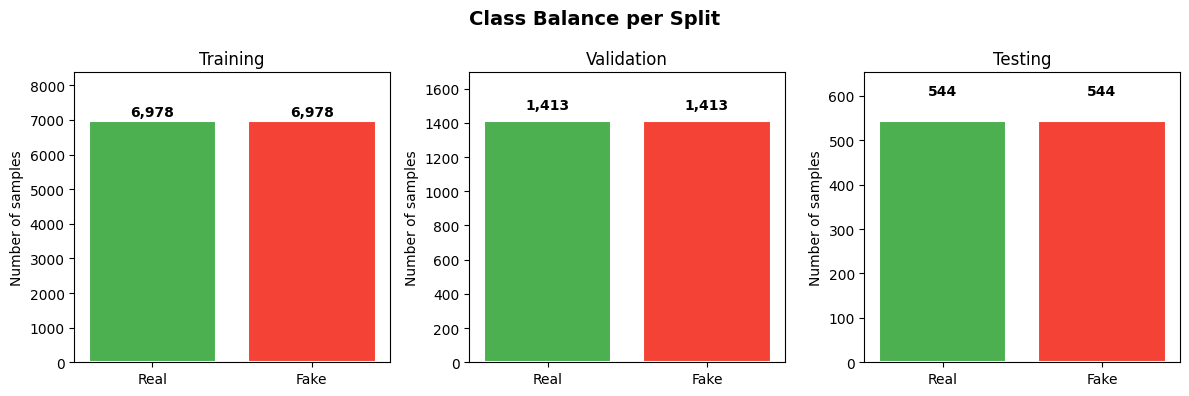

Saved → outputs/class_balance.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Class Balance per Split', fontsize=14, fontweight='bold')

colors = ['#4CAF50', '#F44336']

for ax, split in zip(axes, SPLITS):
    ds = datasets[split]
    labels = [s[1] for s in ds.samples]
    n_real = labels.count(0)
    n_fake = labels.count(1)
    bars = ax.bar(['Real', 'Fake'], [n_real, n_fake], color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(split.capitalize(), fontsize=12)
    ax.set_ylabel('Number of samples')
    ax.set_ylim(0, max(n_real, n_fake) * 1.2)
    for bar, val in zip(bars, [n_real, n_fake]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/class_balance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → outputs/class_balance.png')

---
## 8. Visual Inspection — Mel Spectrograms

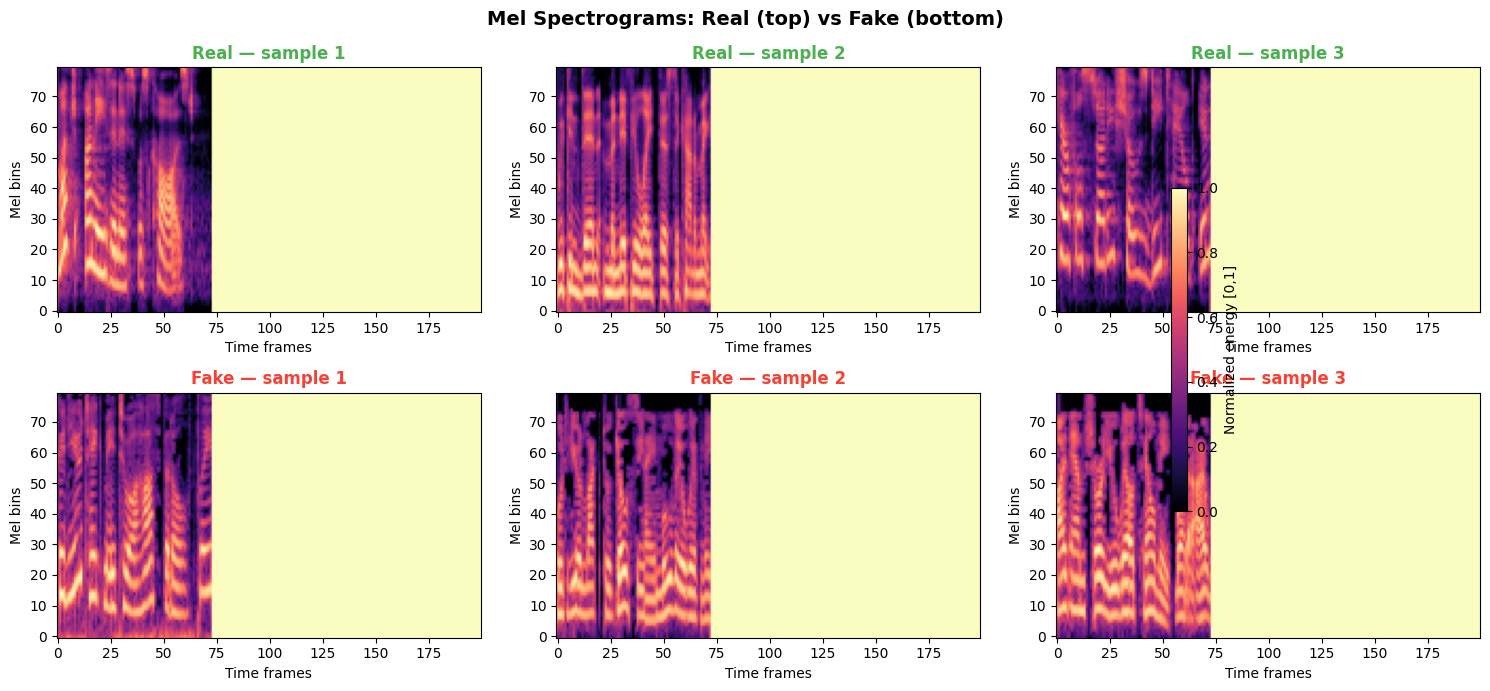

Saved → outputs/mel_spectrograms.png


In [27]:
# Pick 3 real and 3 fake samples from training
n_show = 3
fig, axes = plt.subplots(2, n_show, figsize=(15, 7))
fig.suptitle('Mel Spectrograms: Real (top) vs Fake (bottom)', fontsize=14, fontweight='bold')

for col in range(n_show):
    for row, (files, label_name) in enumerate([(real_files, 'Real'), (fake_files, 'Fake')]):
        audio, _ = sf.read(str(files[col]), dtype='float32')
        if audio.ndim == 2: audio = audio.mean(axis=1)
        mel = extract(audio)

        ax = axes[row][col]
        im = ax.imshow(mel, aspect='auto', origin='lower',
                       cmap='magma', vmin=0, vmax=1)
        ax.set_xlabel('Time frames')
        ax.set_ylabel('Mel bins')
        title_color = '#4CAF50' if label_name == 'Real' else '#F44336'
        ax.set_title(f'{label_name} — sample {col+1}', color=title_color, fontweight='bold')

plt.colorbar(im, ax=axes.ravel().tolist(), label='Normalized energy [0,1]', shrink=0.6)
plt.tight_layout()
plt.savefig('../outputs/mel_spectrograms.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → outputs/mel_spectrograms.png')

---
## 9. Waveform Comparison — Real vs Fake

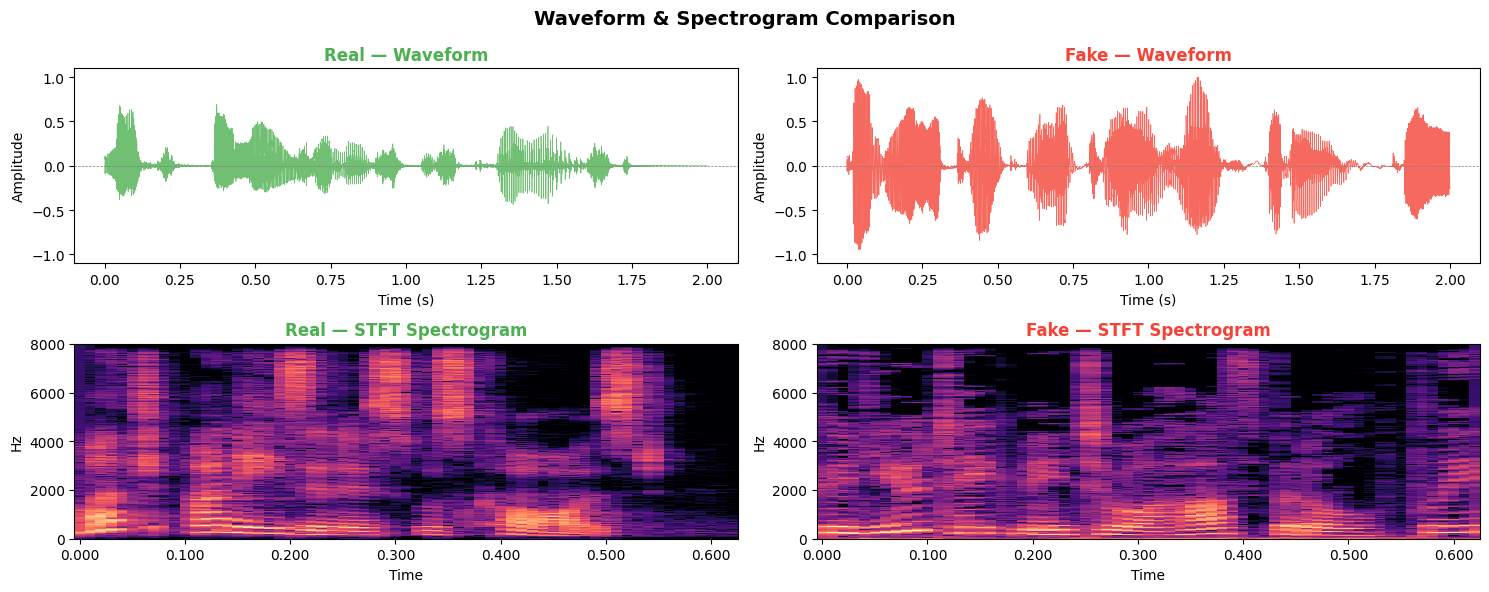

Saved → outputs/waveform_comparison.png


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 6))
fig.suptitle('Waveform & Spectrogram Comparison', fontsize=14, fontweight='bold')

for col, (audio, sr, label_name, color) in enumerate([
    (real_audio, real_sr, 'Real', '#4CAF50'),
    (fake_audio, fake_sr, 'Fake', '#F44336'),
]):
    t = np.linspace(0, len(audio)/sr, len(audio))

    # Waveform
    axes[0][col].plot(t, audio, color=color, linewidth=0.5, alpha=0.8)
    axes[0][col].set_title(f'{label_name} — Waveform', color=color, fontweight='bold')
    axes[0][col].set_xlabel('Time (s)')
    axes[0][col].set_ylabel('Amplitude')
    axes[0][col].set_ylim(-1.1, 1.1)
    axes[0][col].axhline(0, color='gray', linewidth=0.5, linestyle='--')

    # Raw spectrogram (not mel) for comparison
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    librosa.display.specshow(D, sr=sr, hop_length=160,
                              x_axis='time', y_axis='hz', ax=axes[1][col], cmap='magma')
    axes[1][col].set_title(f'{label_name} — STFT Spectrogram', color=color, fontweight='bold')
    axes[1][col].set_ylim(0, 8000)

plt.tight_layout()
plt.savefig('../outputs/waveform_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → outputs/waveform_comparison.png')

---
## 10. ✅ Final Handoff Checklist

In [29]:
from src.data.dataset import build_tf_datasets, build_arrays
from src.features.mel_spectrogram import extract, set_preset

checks = []

# 1. Imports work
try:
    import src.data.dataset
    import src.features.mel_spectrogram
    checks.append(('Imports', True, 'src.data.dataset, src.features.mel_spectrogram'))
except Exception as e:
    checks.append(('Imports', False, str(e)))

# 2. Mel shape correct
try:
    set_preset('for-2sec')
    dummy = np.zeros(32000, dtype=np.float32)
    mel = extract(dummy)
    ok = mel.shape == (80, _cfg['target_frames']) and mel.dtype == np.float32
    checks.append(('Mel shape', ok, f'{mel.shape} float32'))
except Exception as e:
    checks.append(('Mel shape', False, str(e)))

# 3. Dataset loads
try:
    ds = FoRDataset(DATASET_DIR, split='training')
    checks.append(('FoRDataset loads', True, f'{len(ds):,} training samples'))
except Exception as e:
    checks.append(('FoRDataset loads', False, str(e)))

# 4. get_item returns correct shape
try:
    x, y = ds.get_item(0)
    ok = x.shape == (1, 80, _cfg['target_frames'])
    checks.append(('get_item shape', ok, f'{x.shape}'))
except Exception as e:
    checks.append(('get_item shape', False, str(e)))

# 5. build_tf_datasets
try:
    tr, v, te = build_tf_datasets(DATASET_DIR, preset='for-2sec', batch_size=4)
    for xb, yb in tr.take(1):
        ok = xb.shape == (4, 1, 80, _cfg['target_frames'])
    checks.append(('build_tf_datasets', ok, f'batch shape {xb.shape}'))
except Exception as e:
    checks.append(('build_tf_datasets', False, str(e)))

# 6. Both splits have data
try:
    for split in ['training', 'validation', 'testing']:
        ds_s = FoRDataset(DATASET_DIR, split=split)
        assert len(ds_s) > 0
    checks.append(('All splits populated', True, 'training / validation / testing'))
except Exception as e:
    checks.append(('All splits populated', False, str(e)))

# 7. Labels are 0 or 1 only
try:
    ds_check = FoRDataset(DATASET_DIR, split='training')
    labels = set(s[1] for s in ds_check.samples)
    ok = labels == {0, 1}
    checks.append(('Labels are 0/1 only', ok, f'found labels: {labels}'))
except Exception as e:
    checks.append(('Labels are 0/1 only', False, str(e)))

# ── Print results ─────────────────────────────────────────────
print('=' * 65)
print('  HANDOFF CHECKLIST')
print('=' * 65)
all_passed = True
for name, passed, detail in checks:
    icon = '✅' if passed else '❌'
    print(f'  {icon}  {name:<28s}  {detail}')
    if not passed:
        all_passed = False
print('=' * 65)
if all_passed:
    print('  🎉 ALL CHECKS PASSED — pipeline is ready for the model team!')
    print()
    print('  Teammates should use:')
    print('    from src.data.dataset import build_tf_datasets')
    print(f'    train_ds, val_ds, test_ds = build_tf_datasets(')
    print(f'        dataset_dir="data/raw/for-2seconds",')
    print(f'        preset="for-2sec", batch_size=32')
    print(f'    )')
    print(f'    # Input shape to model: (batch, 1, 80, {_cfg["target_frames"]})')
    print(f'    # Labels: 0 = real, 1 = fake')
else:
    print('  ⚠️  Some checks failed — fix them before handing off.')
print('=' * 65)

  training    : 13,956 samples
  training    : 13,956 samples
  validation  :  2,826 samples
  testing     :  1,088 samples
  training    : 13,956 samples
  validation  :  2,826 samples
  testing     :  1,088 samples
  training    : 13,956 samples
  HANDOFF CHECKLIST
  ✅  Imports                       src.data.dataset, src.features.mel_spectrogram
  ✅  Mel shape                     (80, 200) float32
  ✅  FoRDataset loads              13,956 training samples
  ✅  get_item shape                (1, 80, 200)
  ✅  build_tf_datasets             batch shape (4, 1, 80, 200)
  ✅  All splits populated          training / validation / testing
  ✅  Labels are 0/1 only           found labels: {0, 1}
  🎉 ALL CHECKS PASSED — pipeline is ready for the model team!

  Teammates should use:
    from src.data.dataset import build_tf_datasets
    train_ds, val_ds, test_ds = build_tf_datasets(
        dataset_dir="data/raw/for-2seconds",
        preset="for-2sec", batch_size=32
    )
    # Input shape to mo